In [57]:
import pandas as pd
import numpy as np

from pathlib import Path

In [58]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Exam")

In [59]:
exam_results = pd.read_excel(exam_result_path.joinpath("2024-02-05_BPOS_Exam_Results.xlsx"))
exam_results.dropna(subset=["Login"],inplace=True, how="all")
exam_results.head()

,Name,Login,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,...,07_Basics,11_Worst_Practices_Examples,02_Matching_Definitions,06_Missing_Data,09_OA_publishing_types,09_Copyright,04_Ethics_Commission,03_Preregistration_challenges,06_Artifact_Outlier,09_self-archiving
0,"Almohammadi, Fatma",up38ijep,1.0,1.0,58.0,90.0,passed,41.0,41.0,100%,...,0,2,4,0,2.5,0,2.5,0,1,1.5
2,"Balaji, Subhashini Priyanka",yz45eryf,1.0,1.0,69.5,90.0,passed,41.0,41.0,100%,...,2,1,2.5,1,3.5,1,0,1,4,1.5
4,"Bisalehalli Sureshbabu, Mithun",ki69sefa,1.0,1.0,54.0,90.0,passed,31.0,41.0,75.609756097561%,...,2,NaN,2,2,1.5,3,2,1,2,1.5
6,"Boote, Sriparna",ib35olyr,1.0,1.0,66.0,90.0,passed,40.0,41.0,97.560975609756%,...,1,1,0,1,1.5,0.5,0,2,2,2.5
8,"Chakraborty, Biswarup",ab67emem,1.0,1.0,65.0,90.0,passed,40.0,41.0,97.560975609756%,...,0,2,1.5,1,2,1,2.5,2,4,1


In [60]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,...,07_Basics,11_Worst_Practices_Examples,02_Matching_Definitions,06_Missing_Data,09_OA_publishing_types,09_Copyright,04_Ethics_Commission,03_Preregistration_challenges,06_Artifact_Outlier,09_self-archiving
student_id,,,,,,,,,,,,,,,,,,,,,
up38ijep,"Almohammadi, Fatma",1.0,1.0,58.0,90.0,passed,41.0,41.0,100%,00:55:26,...,0,2,4,0,2.5,0,2.5,0,1,1.5
yz45eryf,"Balaji, Subhashini Priyanka",1.0,1.0,69.5,90.0,passed,41.0,41.0,100%,00:43:20,...,2,1,2.5,1,3.5,1,0,1,4,1.5
ki69sefa,"Bisalehalli Sureshbabu, Mithun",1.0,1.0,54.0,90.0,passed,31.0,41.0,75.609756097561%,00:41:05,...,2,NaN,2,2,1.5,3,2,1,2,1.5
ib35olyr,"Boote, Sriparna",1.0,1.0,66.0,90.0,passed,40.0,41.0,97.560975609756%,00:54:47,...,1,1,0,1,1.5,0.5,0,2,2,2.5
ab67emem,"Chakraborty, Biswarup",1.0,1.0,65.0,90.0,passed,40.0,41.0,97.560975609756%,00:47:38,...,0,2,1.5,1,2,1,2.5,2,4,1


<Axes: >

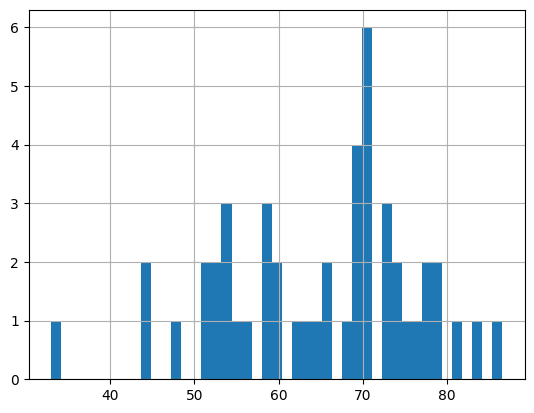

In [61]:
points = exam_results["Test Results in Points"]
points.hist(bins=45)

In [62]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
up38ijep,58.0
yz45eryf,69.5
ki69sefa,54.0
ib35olyr,66.0
ab67emem,65.0


In [63]:
pass_score = 45.0
max_score = 90.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

4.1

In [64]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [65]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[36.8,
 40.9,
 45.0,
 49.1,
 53.2,
 57.3,
 61.4,
 65.5,
 69.6,
 73.69999999999999,
 77.8,
 81.9,
 86.0]

In [66]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,81.9,90.0
1.33,77.8,81.8
1.66,73.7,77.7
2.00,69.6,73.6
2.33,65.5,69.5
2.66,61.4,65.4
3.00,57.3,61.3
3.33,53.2,57.2
3.66,49.1,53.1


In [67]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
up38ijep,58.0,3.00
yz45eryf,69.5,2.33
ki69sefa,54.0,3.33
ib35olyr,66.0,2.33
ab67emem,65.0,2.66
we15jori,71.0,2.00
gy75geko,52.0,3.66
ob02ubig,70.5,2.00
za67salo,68.0,2.33


<Axes: >

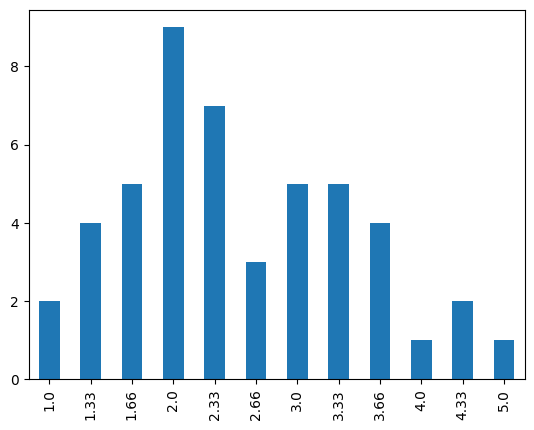

In [68]:
# Without Bonus

points["grade"].value_counts().sort_index().plot(kind="bar")

In [69]:
points["grade"].describe()

count    48.000000
mean      2.538750
std       0.936668
min       1.000000
25%       2.000000
50%       2.330000
75%       3.330000
max       5.000000
Name: grade, dtype: float64

In [70]:
bonus_points = pd.read_excel("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Exercise/WS23_24_Results/result_final.xlsx")
#rename column idm to identifier 
bonus_points.rename(columns={"idm":"student_id"}, inplace=True)
bonus_points.set_index("student_id", inplace=True)
bonus_points

,passed,bonus
student_id,,
ac13atok,6,0.66
al96amyg,1,0.00
an46ykim,6,0.66
ax73aqur,1,0.00
bi30lojy,6,0.66
fi89bipe,2,0.00
fu40panu,3,0.00
fy02myxa,2,0.00
ga20lydi,2,0.00


In [71]:
# join dataframes
points = points.join(bonus_points, how="left")
points.fillna(0, inplace=True)

#points.drop("student_id", axis=1, inplace=True)
points

,points,grade,passed,bonus
student_id,,,,
up38ijep,58.0,3.00,3.0,0.00
yz45eryf,69.5,2.33,2.0,0.00
ki69sefa,54.0,3.33,0.0,0.00
ib35olyr,66.0,2.33,2.0,0.00
ab67emem,65.0,2.66,0.0,0.00
we15jori,71.0,2.00,6.0,0.66
gy75geko,52.0,3.66,0.0,0.00
ob02ubig,70.5,2.00,0.0,0.00
za67salo,68.0,2.33,3.0,0.00


In [72]:
points.drop("passed", axis=1, inplace=True)

In [73]:
points

,points,grade,bonus
student_id,,,
up38ijep,58.0,3.00,0.00
yz45eryf,69.5,2.33,0.00
ki69sefa,54.0,3.33,0.00
ib35olyr,66.0,2.33,0.00
ab67emem,65.0,2.66,0.00
we15jori,71.0,2.00,0.66
gy75geko,52.0,3.66,0.00
ob02ubig,70.5,2.00,0.00
za67salo,68.0,2.33,0.00


In [74]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

,points,grade,bonus,grade_with_bonus
student_id,,,,
up38ijep,58.0,3.00,0.00,3.00
yz45eryf,69.5,2.33,0.00,2.33
ki69sefa,54.0,3.33,0.00,3.33
ib35olyr,66.0,2.33,0.00,2.33
ab67emem,65.0,2.66,0.00,2.66
we15jori,71.0,2.00,0.66,1.34
gy75geko,52.0,3.66,0.00,3.66
ob02ubig,70.5,2.00,0.00,2.00
za67salo,68.0,2.33,0.00,2.33


In [75]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
nu84byna,86.5,1.0,0.3,1.0
vy30goxy,83.0,1.0,0.3,1.0
el41ezaw,78.0,1.3,0.0,1.3
qo24gufe,81.0,1.3,0.7,1.0
ok62ihoc,78.5,1.3,0.7,1.0
uh87yhit,79.0,1.3,0.3,1.0
se67myvy,77.0,1.7,0.7,1.0
we70xebi,74.0,1.7,0.7,1.0
fi89bipe,76.5,1.7,0.0,1.7


In [76]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,48.000000,48.000000,48.000000,48.00000
mean,64.958333,2.537500,0.156250,2.43125
std,11.502467,0.936636,0.276687,1.00555
min,33.000000,1.000000,0.000000,1.00000
25%,55.875000,2.000000,0.000000,1.70000
50%,68.500000,2.300000,0.000000,2.30000
75%,73.000000,3.300000,0.300000,3.00000
max,86.500000,5.000000,0.700000,5.00000


<Axes: >

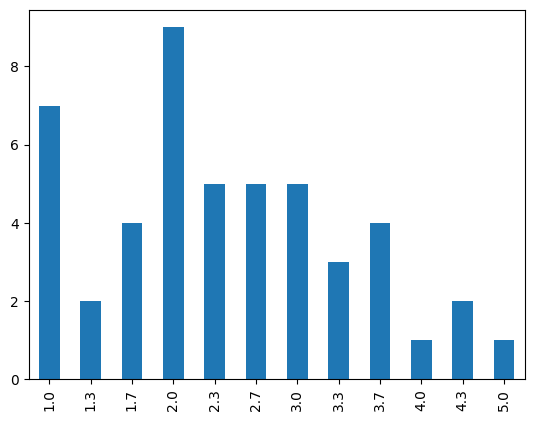

In [77]:
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [78]:
# save to csv
points.to_csv(exam_result_path.joinpath("2023-02_BPOS_Exam_results_final.csv"))